# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
They are interpetable. Latent variable models with activation functions can enforce these restrictions while maintaining the interpretability of the linear structure
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
They are derived from maximum likelihood estimation, which asks: What is the probability of observing these data, given b? They have excellent statistical properties and produce consistent, efficient estimators
3. True or false, and explain: Logistic regression is a linear model.
FALSE
4. True or false, and explain: Logistic regression cannot be used for classification.
False
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
NO I don't think you should, beyond 'Positive means more likely, negative means less likely.
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
False
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.
False

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import seaborn as sns

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

Question 1:Load the data, data.csv. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where Dropout corresponds to dropout and Graduate or Enrolled corresponds to not dropout.

In [22]:
df=pd.read_csv("data.csv",sep=";")
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [23]:
columns = df[['Debtor',
         'Tuition fees up to date',
         'Scholarship holder',
         'Age at enrollment',
         'Curricular units 1st sem (approved)',
         'Target']]

In [24]:
#Handling missing values
df = df.dropna()
#Create binary target: 1 = Dropout, 0 = Not Dropout
df['dropout'] = np.where(df['Target'] == 'Dropout', 1, 0)


Part 2: Run a logistic regression of dropout status on Debtor, Tuition fees up to date, Scholarship holder, and Age at enrollment. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

In [25]:
X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['dropout']
#running logisitc regression
logit = LogisticRegression(penalty=None).fit(X,y)
logit.fit(X, y)
#regression coefficients
# Coefficients
coef = pd.Series(logit.coef_[0], index=X.columns)
print(coef)

Debtor                     0.527137
Tuition fees up to date   -2.605617
Scholarship holder        -1.242299
Age at enrollment          0.049841
dtype: float64


high probability of dropout is people in debt and low probability is people that are up to date on their tution fees. Being up to date on paying tuition fees does lower dropout rate significantly.

part 3: Use .predict_proba and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against Age at enrollment, hued by Tuition fees up to date. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

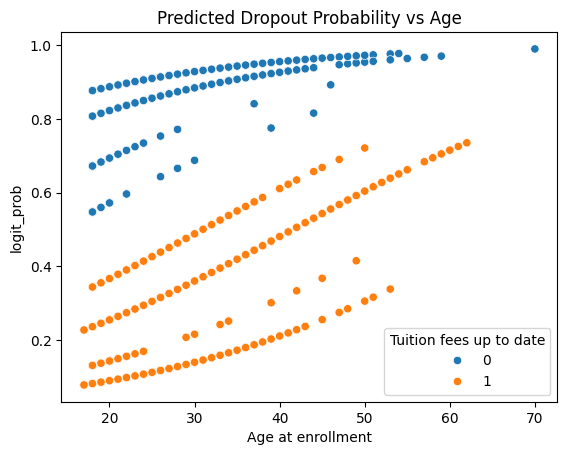

In [26]:
#predicting probabilities
df['logit_prob'] = logit.predict_proba(X)[:,1]

#Creating Scatter plot for visualization
plt.figure()
sns.scatterplot(
    data=df,
    x='Age at enrollment',
    y='logit_prob',
    hue='Tuition fees up to date'
)
plt.title('Predicted Dropout Probability vs Age')
plt.show()

In [27]:
#tuition effect
avg_prob_by_tuition = df.groupby('Tuition fees up to date')['logit_prob'].mean()
print(avg_prob_by_tuition)
print("Difference (1 - 0):", avg_prob_by_tuition[1] - avg_prob_by_tuition[0])

Tuition fees up to date
0    0.865533
1    0.247433
Name: logit_prob, dtype: float64
Difference (1 - 0): -0.6181006153586197


from ages 20-30 (the younger ages it makes the most difference). Being up to date on tuiton payments is a high percentage increase in not dropping out

part four: Use .predict and compute a confusion matrix for your classifier. What is the accuracy?

In [28]:
y_pred = logit.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print(cm)
print("Accuracy:", acc)

[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


part five: Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance

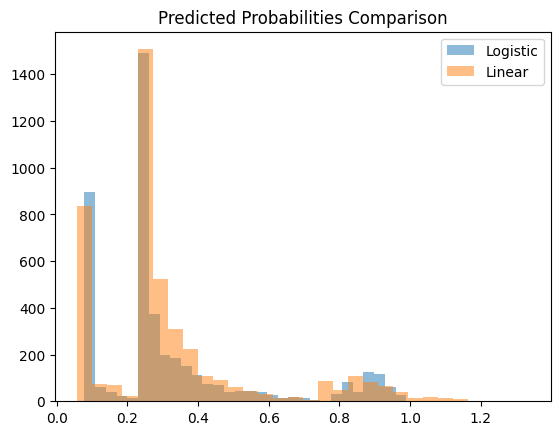

In [29]:
lin = LinearRegression()
lin.fit(X, y)

df['lin_prob'] = lin.predict(X)

# Histogram comparison
plt.figure()
plt.hist(df['logit_prob'], bins=30, alpha=0.5, label='Logistic')
plt.hist(df['lin_prob'], bins=30, alpha=0.5, label='Linear')
plt.legend()
plt.title('Predicted Probabilities Comparison')
plt.show()

linear is overall much higher result model data than logistical result data

Part six: Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

students that are not up to date with paying tuiton fees. Interventions of financial aid and paying college could be helpful from preventing not paying fees and leading to dropout

part seven: Run a multinomial logistic regression of Target on Debtor, Tuition fees up to date, and Curricular units 1st sem (approved). Use .predict to make a hard classification, and compute a confusion matrix. Describe your results. Use .predict_proba to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [30]:
X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

multi = LogisticRegression(multi_class='multinomial', max_iter=1000)
multi.fit(X_multi, y_multi)

# Hard predictions
y_multi_pred = multi.predict(X_multi)

cm_multi = confusion_matrix(y_multi, y_multi_pred)
print(cm_multi)

# Probabilities
multi_probs = multi.predict_proba(X_multi)
print(multi_probs[:5])

[[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]
[[0.68054695 0.21046429 0.10898876]
 [0.69541412 0.1460432  0.15854268]
 [0.95298821 0.04119918 0.00581261]
 [0.11780804 0.1769832  0.70520876]
 [0.18422683 0.21266883 0.60310434]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


they do not predict all predicted classes. My results tell me that there is not negative correlation with any of my data analysis done

question six: Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

part one:Load the data, cirrhosis.csv. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

In [31]:
df = pd.read_csv('cirrhosis.csv')


In [32]:
cols = ['Status', 'Edema', 'Drug', 'Bilirubin', 'Stage']
df = df[cols]

In [33]:
#dropping missing values:
df = df.dropna()

part two: Run a logistic regression of Status on Edema, Drug, and Bilirubin. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

In [34]:
#processing the cirrhosis data
df['Survival_Status'] = df['Status'].apply(lambda x: 1 if x in ['C', 'CL'] else 0)

# encoding the categorical variables 'Edema' and 'Drug'
df_encoded = pd.get_dummies(df, columns=['Edema', 'Drug'], drop_first=True)

# Define X and y for the cirrhosis problem
X_cirrhosis = df_encoded[['Bilirubin', 'Edema_S', 'Edema_Y', 'Drug_Placebo']]
y_cirrhosis = df_encoded['Survival_Status']

# Fit logistic regression for cirrhosis data
logreg_cirrhosis = LogisticRegression(penalty=None, max_iter=5000)
logreg_cirrhosis.fit(X_cirrhosis, y_cirrhosis)

# Display coefficients (my answers I need)
coef_df_cirrhosis = pd.DataFrame({
    'Variable': X_cirrhosis.columns,
    'Coefficient': logreg_cirrhosis.coef_[0]
})
print("\nLogistic Regression Coefficients for Cirrhosis Data:")
print(coef_df_cirrhosis)


Logistic Regression Coefficients for Cirrhosis Data:
       Variable  Coefficient
0     Bilirubin    -0.350381
1       Edema_S    -0.578551
2       Edema_Y    -2.859322
3  Drug_Placebo     0.252657


part three:Use .predict_proba and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against Bilirubin, hued by Drug. For what values of Bilirubin does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

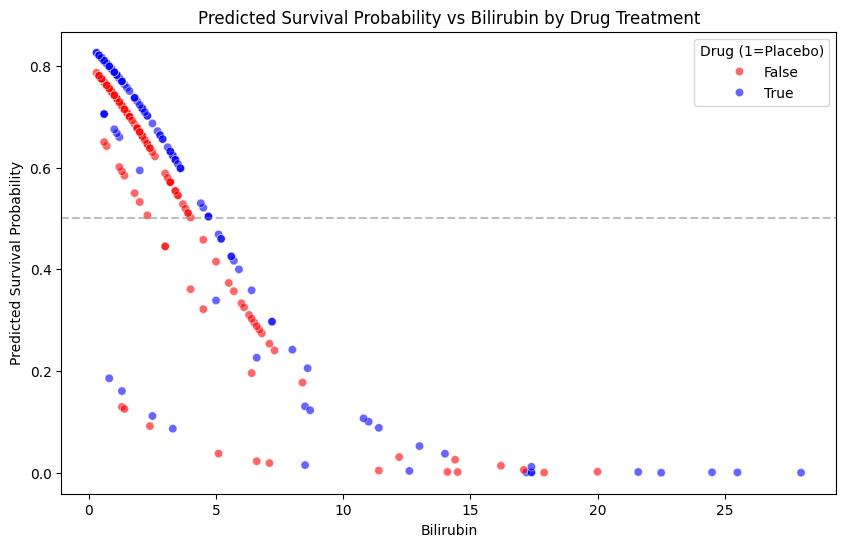

In [35]:
# Get predicted probabilities for survival using the fitted model
y_proba_cirrhosis = logreg_cirrhosis.predict_proba(X_cirrhosis)
df_encoded['Predicted_Survival'] = y_proba_cirrhosis[:, 1]
 # Probability of survival

# Scatter plot of predicted survival probability against Bilirubin, which is hued by Drug
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_encoded, x='Bilirubin', y='Predicted_Survival',
                hue='Drug_Placebo', alpha=0.6, palette=['red', 'blue'])
plt.xlabel('Bilirubin')
plt.ylabel('Predicted Survival Probability')
plt.title('Predicted Survival Probability vs Bilirubin by Drug Treatment')
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
plt.legend(title='Drug (1=Placebo)')
plt.show()

In [36]:
# Calculate average predicted survival probability for D-penicillamine group
avg_prob_d_penicillamine = df_encoded[df_encoded['Drug_Placebo'] == False]['Predicted_Survival'].mean()

# Calculate average predicted survival probability for Placebo group
avg_prob_placebo = df_encoded[df_encoded['Drug_Placebo'] == True]['Predicted_Survival'].mean()

print(f"Average predicted survival probability for D-penicillamine: {avg_prob_d_penicillamine:.4f}")
print(f"Average predicted survival probability for Placebo: {avg_prob_placebo:.4f}")

# Calculate the difference: D-penicillamine probability relative to Placebo
difference = avg_prob_d_penicillamine - avg_prob_placebo
print(f"On average, taking D-penicillamine changes survival probability by: {difference:.4f}")

Average predicted survival probability for D-penicillamine: 0.5886
Average predicted survival probability for Placebo: 0.6104
On average, taking D-penicillamine changes survival probability by: -0.0218


part four: Use .predict and compute a confusion matrix for your classifier. What is the accuracy?

In [37]:
y_class = logreg_cirrhosis.predict(X_cirrhosis)

# Confusion matrix
conf_matrix = pd.crosstab(y_class, y_cirrhosis, rownames=['Predicted'], colnames=['Actual'])
print("\nConfusion Matrix (rows=Predicted, cols=Actual, 1=Survived, 0=Died):")
print(conf_matrix)

# Accuracy
accuracy = np.trace(conf_matrix) / len(y_class)
print(f"\nAccuracy: {accuracy:.4f}")


Confusion Matrix (rows=Predicted, cols=Actual, 1=Survived, 0=Died):
Actual      0    1
Predicted         
0          57   14
1          68  173

Accuracy: 0.7372


part five: Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

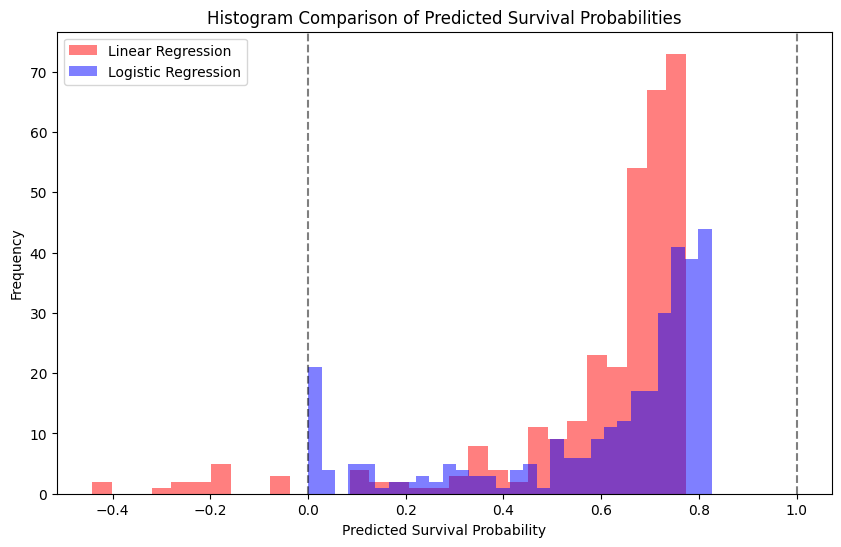

In [38]:
# Linear regression for comparison using the cirrhosis data
linreg_cirrhosis = LinearRegression()
linreg_cirrhosis.fit(X_cirrhosis, y_cirrhosis)
df_encoded['lin_prob_cirrhosis'] = linreg_cirrhosis.predict(X_cirrhosis)

# Histogram comparison
plt.figure(figsize=(10, 6))
plt.hist(df_encoded['lin_prob_cirrhosis'], bins=30, alpha=0.5, label='Linear Regression', color='red')
plt.hist(df_encoded['Predicted_Survival'], bins=30, alpha=0.5, label='Logistic Regression', color='blue')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5)
plt.xlabel('Predicted Survival Probability')
plt.ylabel('Frequency')
plt.title('Histogram Comparison of Predicted Survival Probabilities')
plt.legend()
plt.show()

linear is much higher overall in frequency compared to logistical regression

part six: Run a logistic regression of Stage on Edema and Bilirubin. Use .predict to make a hard classification, and compute a confusion matrix. Describe your results. Use .predict_proba to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [39]:
# Prepare data for Stage prediction
X_stage = df_encoded[['Edema_S', 'Edema_Y', 'Bilirubin']]
y_stage = df_encoded['Stage']

print(f"Stage distribution:")
print(y_stage.value_counts().sort_index())

# Fit multinomial logistic regression
y_stage = y_stage.astype(int)
mnl_stage = LogisticRegression(penalty=None, max_iter=5000)
mnl_stage = mnl_stage.fit(X_stage, y_stage)
# Hard classification
y_stage_pred = mnl_stage.predict(X_stage)

# Confusion matrix for Stage
stage_conf = pd.crosstab(y_stage_pred, y_stage, rownames=['Predicted'], colnames=['Actual'])
print("\nConfusion Matrix for Stage Prediction:")
print(stage_conf)

# Probabilities
stage_probs = mnl_stage.predict_proba(X_stage)
print("\nPredicted Probabilities (first 5 samples):\n", stage_probs[:5])


Stage distribution:
Stage
1.0     16
2.0     67
3.0    120
4.0    109
Name: count, dtype: int64

Confusion Matrix for Stage Prediction:
Actual      1   2    3   4
Predicted                 
3          16  61  102  74
4           0   6   18  35

Predicted Probabilities (first 5 samples):
 [[2.96508663e-08 2.25478394e-02 1.24085408e-01 8.53366723e-01]
 [7.61133775e-02 2.52746893e-01 3.97285699e-01 2.73854031e-01]
 [2.40487685e-07 1.75628382e-01 4.04098555e-01 4.20272823e-01]
 [1.88742531e-07 1.70140290e-01 4.03069927e-01 4.26789594e-01]
 [2.05381601e-02 2.28844619e-01 4.25472446e-01 3.25144776e-01]]


no I did not predict hard classifications for every class and my predicted do not cover every class as some are not included

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

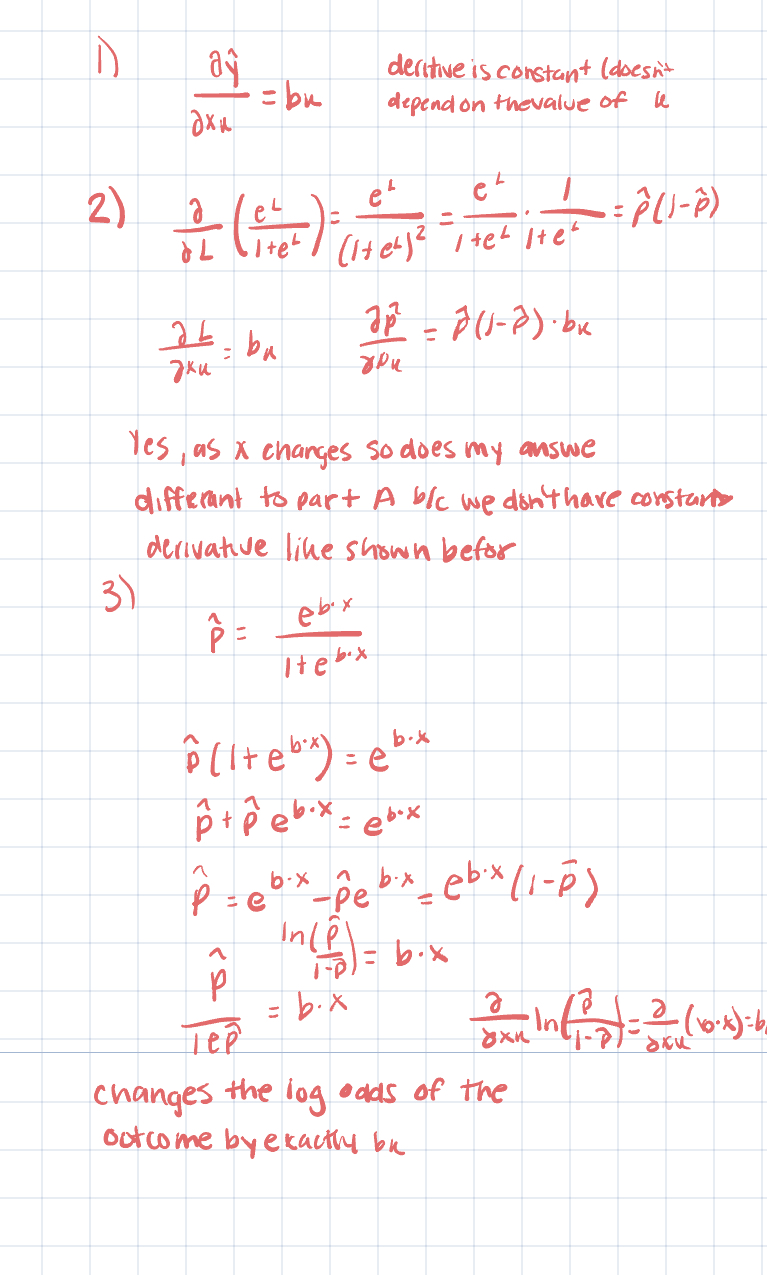

In [40]:
from IPython.display import Image
Image('/content/IMG_0592.jpg')
